In [2]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import numpy as np
import torch
import torch.nn.functional as F
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys

CODE_DIR    = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code'
CKPT_DIR    = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/training'
BASE_OUTPUT = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/test'
os.makedirs(BASE_OUTPUT, exist_ok=True)
sys.path.append(CODE_DIR)

from lib.model.Baseline      import CNN
from lib.model.FusionNet     import FusionNet
from lib.model.FusionNetRes  import FusionNetRes
from lib.model.FusionNetASPP import FusionNetASPP

### ── Only change these ──────────────────────────────────────────────────
MODEL_NAME = 'fusionnetaspp'   # 'baseline' | 'fusionnet' | 'fusionnetres' | 'fusionnetaspp'
POSTFIX    = '3'

# Paths
OUTPUT_DIR = os.path.join(BASE_OUTPUT, MODEL_NAME + POSTFIX)
os.makedirs(OUTPUT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, MODEL_NAME, f'best_model_{POSTFIX}.pth')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load checkpoint
ckpt        = torch.load(CKPT_PATH, map_location=device, weights_only=True)
in_channels = ckpt['in_channels']
features    = ckpt['features']
model_name  = ckpt.get('model_name', MODEL_NAME)
print(f'Checkpoint  : epoch={ckpt["epoch"]}  val_rmse={ckpt["val_rmse"]:.2f}%  val_mae={ckpt["val_mae"]:.2f}%')

_registry = {
    'Baseline':      lambda: CNN(in_channels=in_channels, features=features),
    'FusionNet':     lambda: FusionNet(in_channels=in_channels, features=features),
    'FusionNetRes':  lambda: FusionNetRes(in_channels=in_channels, features=features),
    'FusionNetASPP': lambda: FusionNetASPP(in_channels=in_channels, features=features),
}
model = _registry[model_name]().to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Model loaded: {model_name}  features={features}  in_channels={in_channels}')

# Colormaps
cmap_bt   = plt.cm.Greys.copy();   cmap_bt.set_bad('beige')
cmap_sic  = plt.cm.Blues_r.copy(); cmap_sic.set_bad('lightgray')
cmap_diff = plt.cm.bwr.copy();     cmap_diff.set_bad('lightgray')

Using device: cuda


/dmidata/users/nili/miniforge3/envs/master/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Checkpoint  : epoch=177  val_rmse=5.90%  val_mae=2.39%
Model loaded: FusionNetASPP  features=128  in_channels=14


### Predict from unseen AMSR2 + SIC pair

AMSR2 : /dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2/2021/02/04/AMSR2_S1A_EW_GRDM_1SDH_20210204T053353_20210204T053457_036436_0446EB_F69C.nc
SIC   : /dmidata/projects/asip-cms/reproc/2021/02/04/S1A_EW_GRDM_1SDH_20210204T053353_20210204T053457_036436_0446EB_F69C_SIC.tiff
AMSR2: (14, 214, 207)
SIC: (214, 207)  valid pixels: 35350


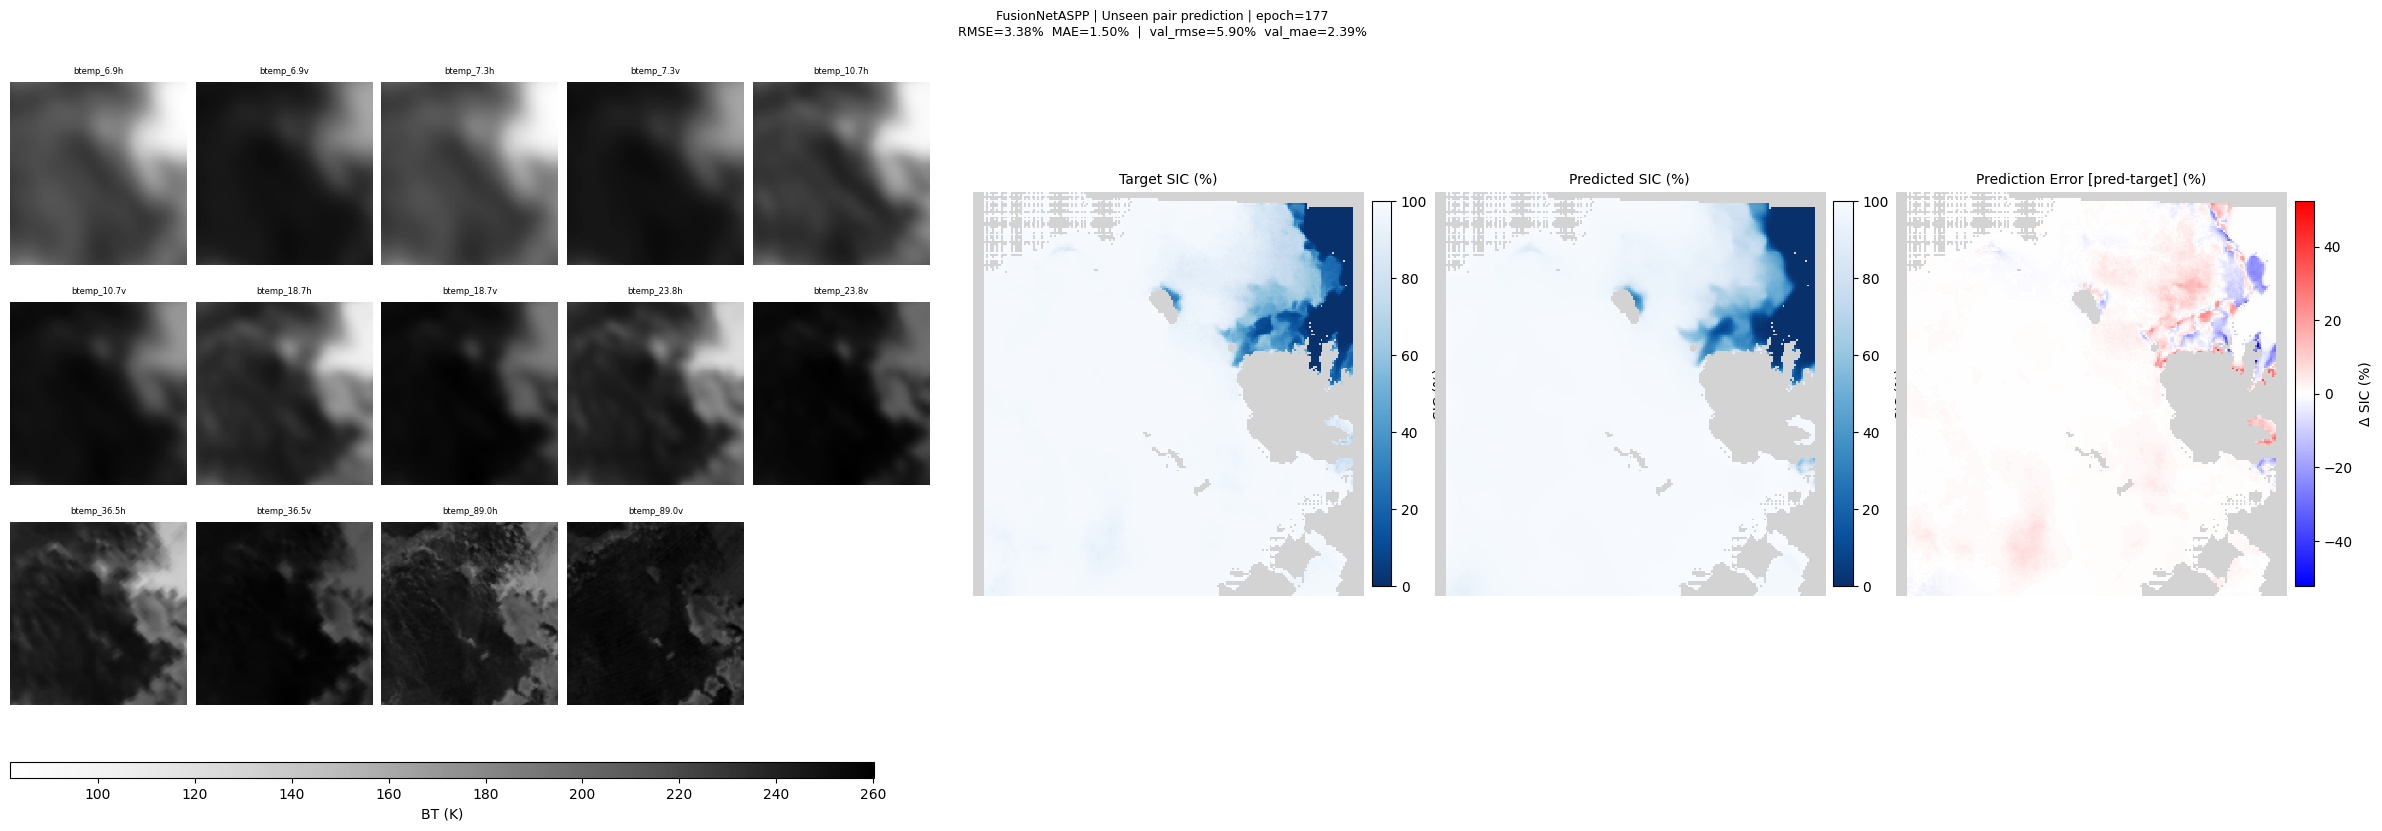

Unseen pair — RMSE: 3.38%  MAE: 1.50%


In [8]:
AMSR2_PATH_PAIR = '/dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2/2021/02/04/AMSR2_S1A_EW_GRDM_1SDH_20210204T053353_20210204T053457_036436_0446EB_F69C.nc'
SIC_BASE_DIR    = '/dmidata/projects/asip-cms/reproc'

# Derive SIC path from AMSR2 filename
amsr2_basename  = os.path.basename(AMSR2_PATH_PAIR)  
scene_id        = amsr2_basename.replace('AMSR2_', '').replace('.nc', '')  
sic_filename    = scene_id + '_SIC.tiff'                    

parts    = AMSR2_PATH_PAIR.split('/')
date_idx = parts.index('AMSR2') + 1                           # find AMSR2 dir then step forward
y, m, d  = parts[date_idx], parts[date_idx+1], parts[date_idx+2]

SIC_PATH_PAIR = os.path.join(SIC_BASE_DIR, y, m, d, sic_filename)
print(f'AMSR2 : {AMSR2_PATH_PAIR}')
print(f'SIC   : {SIC_PATH_PAIR}')
assert os.path.exists(SIC_PATH_PAIR), f'SIC file not found: {SIC_PATH_PAIR}'

# Load AMSR2
with xr.open_dataset(AMSR2_PATH_PAIR, engine='h5netcdf') as ds:
    ch_names  = [v for v in ds.data_vars if 'swath' not in v.lower()]
    amsr2_np  = ds[ch_names].to_array().values.astype(np.float32)
amsr2_h, amsr2_w = amsr2_np.shape[-2], amsr2_np.shape[-1]
print(f'AMSR2: {amsr2_np.shape}')

# Load SIC and bicubic-downsample to AMSR2 resolution
with rioxarray.open_rasterio(SIC_PATH_PAIR) as da:
    sic_native = da.values[0].astype(np.float32)  # (H_sic, W_sic)

invalid    = (sic_native == 254) | (sic_native == 255)
sic_filled = sic_native.copy()
sic_filled[invalid] = np.nan

sic_t    = torch.from_numpy(sic_filled)[None, None]
sic_lr_t = F.interpolate(sic_t, size=(amsr2_h, amsr2_w), mode='bicubic', align_corners=False)
sic_lr   = sic_lr_t.numpy()[0, 0]
mask_lr  = np.isnan(sic_lr) | (sic_lr < 0.0) | (sic_lr > 100.0)
sic_lr   = np.clip(sic_lr, 0.0, 100.0)
sic_np   = np.where(mask_lr, np.nan, sic_lr)
print(f'SIC: {sic_np.shape}  valid pixels: {(~mask_lr).sum()}')

# Run inference
amsr2_t     = torch.from_numpy(amsr2_np)[None].to(device)  # (1, 14, H, W)
target_size = (amsr2_h, amsr2_w)

with torch.no_grad():
    pred_t = model(amsr2_t, target_size=target_size)

pred_np = np.clip(pred_t[0, 0].cpu().numpy(), 0, 100)
pred_np = np.where(mask_lr, np.nan, pred_np)
diff_np = pred_np - sic_np
abs_max = np.nanmax(np.abs(diff_np))

# Plot — 4 columns: AMSR2 | Target SIC | Prediction | Difference
fig = plt.figure(figsize=(24, 8))
gs  = gridspec.GridSpec(1, 4, figure=fig,
                        width_ratios=[2.2, 1, 1, 1],
                        left=0.02, right=0.98, top=0.90, bottom=0.10,
                        wspace=0.08)

# AMSR2 channels
gs_ch  = gs[0, 0].subgridspec(3, 5, hspace=0.10, wspace=0.05)
ims_bt = []
for i, ch in enumerate(ch_names[:14]):
    row, col = divmod(i, 5)
    ax = fig.add_subplot(gs_ch[row, col])
    im = ax.imshow(amsr2_np[i], cmap=cmap_bt, interpolation='nearest')
    ax.set_title(ch, fontsize=6)
    ax.axis('off')
    ims_bt.append(im)
if len(ch_names) < 15:
    fig.add_subplot(gs_ch[2, 4]).axis('off')
vmin_bt, vmax_bt = amsr2_np.min(), amsr2_np.max()
for im in ims_bt: im.set_clim(vmin_bt, vmax_bt)
# cax_bt = fig.add_axes([0.02, 0.04, 0.42, 0.015])
cax_bt = fig.add_axes([0.02, 0.02, 0.36, 0.02])
fig.colorbar(ims_bt[0], cax=cax_bt, orientation='horizontal', label='BT (K)')

# Target SIC
ax_tgt = fig.add_subplot(gs[0, 1])
im_tgt = ax_tgt.imshow(sic_np, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
ax_tgt.set_title('Target SIC (%)', fontsize=10)
ax_tgt.axis('off')
plt.colorbar(im_tgt, ax=ax_tgt, fraction=0.046, pad=0.02, label='SIC (%)')

# Prediction
ax_pred = fig.add_subplot(gs[0, 2])
im_pred = ax_pred.imshow(pred_np, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
ax_pred.set_title(f'Predicted SIC (%)', fontsize=10)
ax_pred.axis('off')
plt.colorbar(im_pred, ax=ax_pred, fraction=0.046, pad=0.02, label='SIC (%)')

# Difference
ax_diff = fig.add_subplot(gs[0, 3])
im_diff = ax_diff.imshow(diff_np, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
ax_diff.set_title('Prediction Error [pred-target] (%)', fontsize=10)
ax_diff.axis('off')
plt.colorbar(im_diff, ax=ax_diff, fraction=0.046, pad=0.02, label='Δ SIC (%)')

# Compute metrics on valid pixels
valid    = ~mask_lr
rmse     = np.sqrt(np.nanmean(diff_np[valid]**2))
mae      = np.nanmean(np.abs(diff_np[valid]))

fig.suptitle(
    f'{model_name} | Unseen pair prediction | epoch={ckpt["epoch"]}\n'
    f'RMSE={rmse:.2f}%  MAE={mae:.2f}%  |  '
    f'val_rmse={ckpt["val_rmse"]:.2f}%  val_mae={ckpt["val_mae"]:.2f}%',
    fontsize=9,
)
plt.show()
print(f'Unseen pair — RMSE: {rmse:.2f}%  MAE: {mae:.2f}%')


### Full swath prediction

Reference shape (low freq): 2035 × 243
  Resampling btemp_89.0h: (2035, 486) → (2035, 243)
  Resampling btemp_89.0v: (2035, 486) → (2035, 243)
AMSR2 shape: (14, 2035, 243)  channels: ['btemp_6.9h', 'btemp_6.9v', 'btemp_7.3h', 'btemp_7.3v', 'btemp_10.7h', 'btemp_10.7v', 'btemp_18.7h', 'btemp_18.7v', 'btemp_23.8h', 'btemp_23.8v', 'btemp_36.5h', 'btemp_36.5v', 'btemp_89.0h', 'btemp_89.0v']
Prediction shape: (2035, 243)  min=0.0  max=100.0


/tmp/ipykernel_2688077/3511875107.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


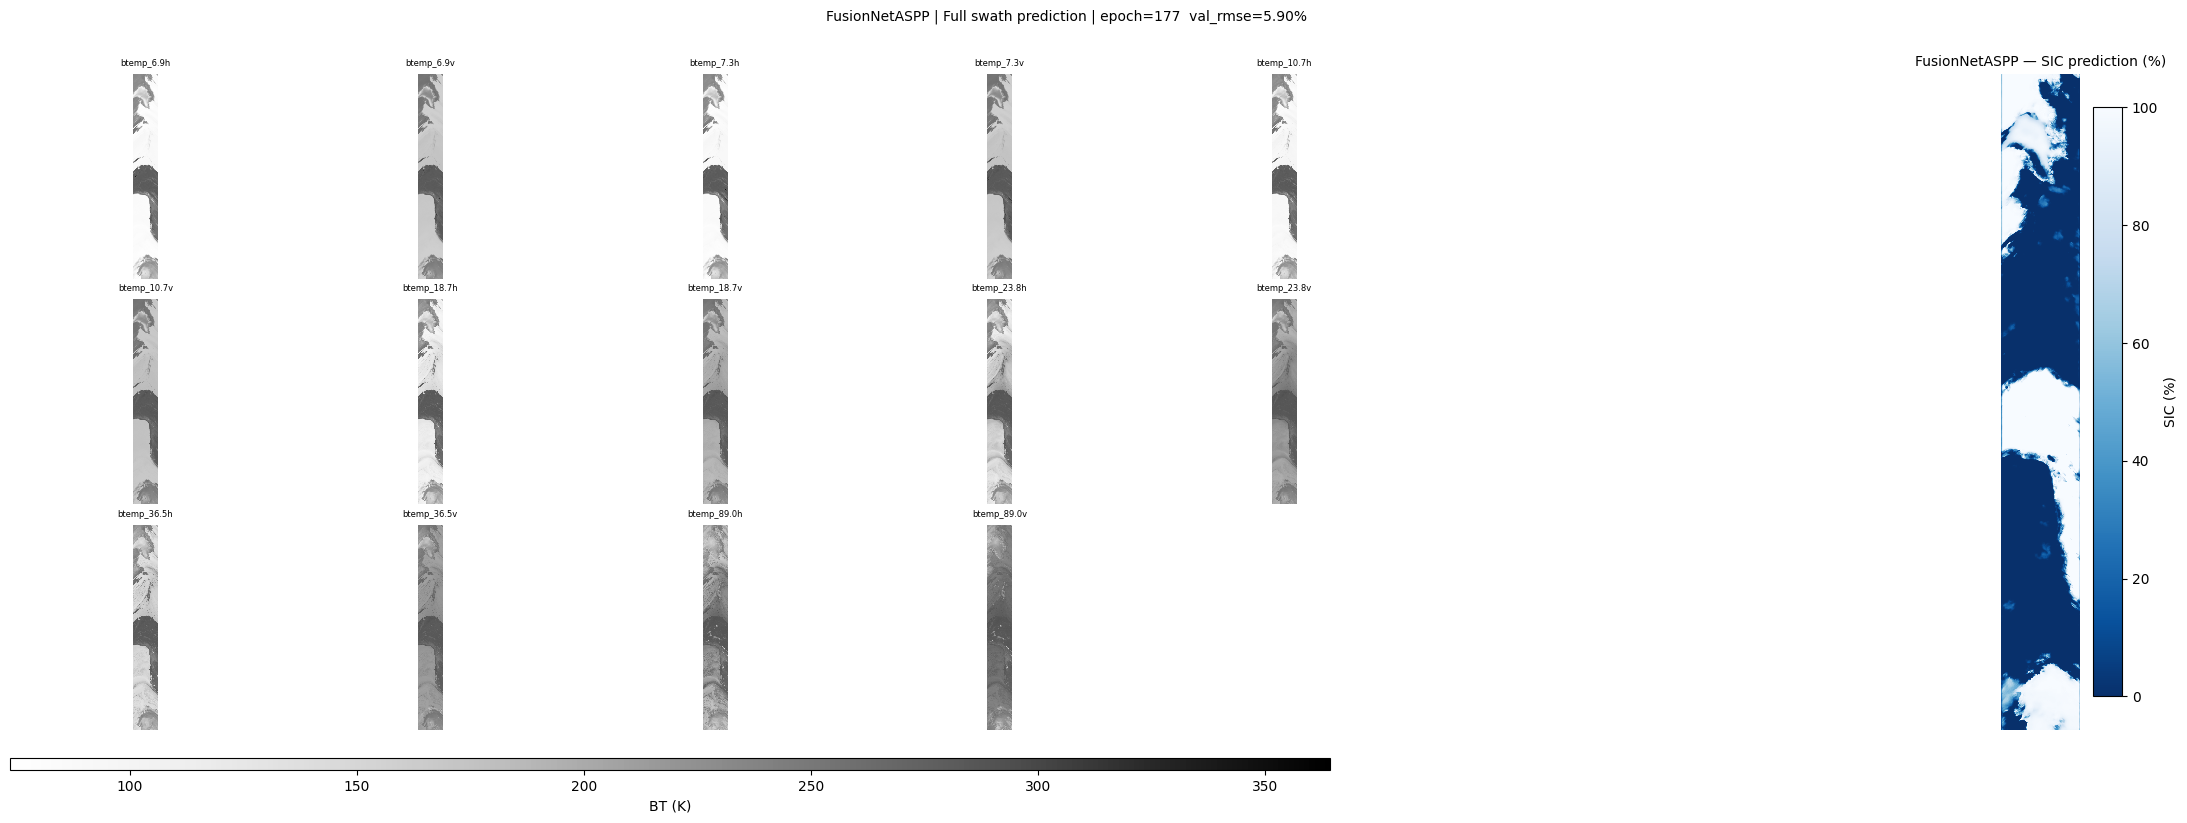

In [19]:
### ── Set path to AMSR2 .h5 swath file ───────────────────────────────────
AMSR2_PATH = '/dmidata/projects/asip-cms/amsr2/2021/02/04/GW1AM2_202102040542_004D_L1SGBTBR_2220220.h5'  # ← change this
### ──────────────────────────────────────────────────────────────────────

# Load AMSR2 swath
with xr.open_dataset(AMSR2_PATH, engine='h5netcdf', phony_dims='sort') as ds:

    # Extract the 14 brightness temperature channels in the same order as training
    # Use 89A (not 89B) for the 89 GHz channels
    bt_vars = {
        'btemp_6.9h':  'Brightness Temperature (6.9GHz,H)',
        'btemp_6.9v':  'Brightness Temperature (6.9GHz,V)',
        'btemp_7.3h':  'Brightness Temperature (7.3GHz,H)',
        'btemp_7.3v':  'Brightness Temperature (7.3GHz,V)',
        'btemp_10.7h': 'Brightness Temperature (10.7GHz,H)',
        'btemp_10.7v': 'Brightness Temperature (10.7GHz,V)',
        'btemp_18.7h': 'Brightness Temperature (18.7GHz,H)',
        'btemp_18.7v': 'Brightness Temperature (18.7GHz,V)',
        'btemp_23.8h': 'Brightness Temperature (23.8GHz,H)',
        'btemp_23.8v': 'Brightness Temperature (23.8GHz,V)',
        'btemp_36.5h': 'Brightness Temperature (36.5GHz,H)',
        'btemp_36.5v': 'Brightness Temperature (36.5GHz,V)',
        'btemp_89.0h': 'Brightness Temperature (89.0GHz-A,H)',  # use 89A
        'btemp_89.0v': 'Brightness Temperature (89.0GHz-A,V)',  # use 89A
    }

    channel_names = list(bt_vars.keys())
    arrays = [ds[v].values.astype(np.float32) for v in bt_vars.values()]

# Reference shape from low-frequency channels (2035, 243)
target_h, target_w = arrays[0].shape
print(f'Reference shape (low freq): {target_h} × {target_w}')

# Downsample 89 GHz (2035, 486) → (2035, 243) to match lower frequency channels
resampled = []
for name, arr in zip(channel_names, arrays):
    if arr.shape != (target_h, target_w):
        print(f'  Resampling {name}: {arr.shape} → ({target_h}, {target_w})')
        t   = torch.from_numpy(arr)[None, None]
        t   = F.interpolate(t, size=(target_h, target_w), mode='bicubic', align_corners=False)
        arr = t.numpy()[0, 0]
    resampled.append(arr)

amsr2_np = np.stack(resampled, axis=0)  # (14, 2035, 243)
amsr2_np = amsr2_np/100.0
print(f'AMSR2 shape: {amsr2_np.shape}  channels: {channel_names}')
assert amsr2_np.shape[0] == 14

# Build model input
amsr2_t = torch.from_numpy(amsr2_np)[None].to(device)  # (1, 14, H, W)
target_size = (amsr2_np.shape[-2], amsr2_np.shape[-1])

with torch.no_grad():
    pred_t = model(amsr2_t, target_size=target_size)

pred_swath = pred_t[0, 0].cpu().numpy()  # (H, W)
pred_swath = np.clip(pred_swath, 0, 100)
print(f'Prediction shape: {pred_swath.shape}  min={pred_swath.min():.1f}  max={pred_swath.max():.1f}')

# Plot — AMSR2 channels (3×5) + prediction
fig = plt.figure(figsize=(22, 8))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2.2, 1],
                        left=0.02, right=0.98, top=0.90, bottom=0.08, wspace=0.06)
gs_ch = gs[0, 0].subgridspec(3, 5, hspace=0.10, wspace=0.05)

ims_bt = []
for i, ch in enumerate(channel_names[:14]):
    row, col = divmod(i, 5)
    ax = fig.add_subplot(gs_ch[row, col])
    im = ax.imshow(amsr2_np[i], cmap=cmap_bt, interpolation='nearest')
    ax.set_title(ch, fontsize=6)
    ax.axis('off')
    ims_bt.append(im)
if len(channel_names) < 15:
    fig.add_subplot(gs_ch[2, 4]).axis('off')

vmin_bt, vmax_bt = amsr2_np.min(), amsr2_np.max()
for im in ims_bt: im.set_clim(vmin_bt, vmax_bt)
cax_bt = fig.add_axes([0.02, 0.03, 0.60, 0.015])
fig.colorbar(ims_bt[0], cax=cax_bt, orientation='horizontal', label='BT (K)')

ax_pred = fig.add_subplot(gs[0, 1])
im_pred = ax_pred.imshow(pred_swath, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
ax_pred.set_title(f'{model_name} — SIC prediction (%)', fontsize=10)
ax_pred.axis('off')
plt.colorbar(im_pred, ax=ax_pred, fraction=0.046, pad=0.02, label='SIC (%)')

fig.suptitle(f'{model_name} | Full swath prediction | epoch={ckpt["epoch"]}  '
             f'val_rmse={ckpt["val_rmse"]:.2f}%', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
with xr.open_dataset(AMSR2_PATH, engine='h5netcdf') as ds:
    print('Variables and shapes:')
    for v in ds.data_vars:
        print(f'  {v}: {ds[v].shape}  dims={ds[v].dims}')

Variables and shapes:
  Attitude Data: (2035, 3)  dims=('phony_dim_0', 'phony_dim_1')
  Brightness Temperature (10.7GHz,H): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (10.7GHz,V): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (18.7GHz,H): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (18.7GHz,V): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (23.8GHz,H): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (23.8GHz,V): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (36.5GHz,H): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (36.5GHz,V): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (6.9GHz,H): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (6.9GHz,V): (2035, 243)  dims=('phony_dim_0', 'phony_dim_2')
  Brightness Temperature (7.3GHz,H): (2035, 24

/tmp/ipykernel_2688077/2622256037.py:1: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  with xr.open_dataset(AMSR2_PATH, engine='h5netcdf') as ds:
